# Aggregated Scalar Conclusions

This notebook contains some quick stats on:
 - `agentic/scalar_experiments/aggregated_results_prompt1.csv`
 - `agentic/scalar_experiments/aggregated_results_prompt2.csv`
 - `agentic/scalar_experiments/aggregated_results_prompt3.csv`
 - `agentic/scalar_experiments/aggregated_results_prompt4.csv`

This includes how conclusions from each prompt vary by dataset and perturbation, to ensure that the null distribution has sufficient spread, and to check that it is centered at a value that makes sense.

In [1]:
# Imports + helpers used across prompts
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# This notebook lives in: agentic/scalar_experiments/insights/
# Aggregated results live in: agentic/scalar_experiments/
BASE_DIR = Path("..").resolve()

PROMPT_PATHS = {
    1: BASE_DIR / "aggregated_results_prompt1.csv",
    2: BASE_DIR / "aggregated_results_prompt2.csv",
    3: BASE_DIR / "aggregated_results_prompt3.csv",
    4: BASE_DIR / "aggregated_results_prompt4.csv",
}

def _norm_yes_no(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    # normalize common variants
    s = s.replace({"y": "yes", "n": "no", "true": "yes", "false": "no"})
    return s

def load_prompt_df(prompt_num: int) -> pd.DataFrame:
    path = PROMPT_PATHS[prompt_num]
    df = pd.read_csv(path)
    return df

def yes_rate_table(df: pd.DataFrame, response_col: str = "response") -> pd.DataFrame:
    resp = _norm_yes_no(df[response_col])
    out = resp.value_counts(dropna=False).to_frame("count")
    out["pct"] = (out["count"] / out["count"].sum() * 100).round(1)
    return out

def yes_rate_by(df: pd.DataFrame, group_col: str, response_col: str = "response") -> pd.DataFrame:
    resp = _norm_yes_no(df[response_col])
    tmp = df.assign(_resp=resp, _yes=(resp == "yes").astype(float))
    out = tmp.groupby(group_col)["_yes"].agg([("yes_rate", "mean"), ("n", "count")]).sort_values("yes_rate")
    out["yes_rate"] = out["yes_rate"].round(3)
    return out

sns.set_style("whitegrid")

## Prompt #1: Just Yes/No

In [2]:
# Prompt 1: Yes/No only
df1 = load_prompt_df(1)
df1 = df1.assign(response_norm=_norm_yes_no(df1["response"]))

print("Prompt 1 — overall")
display(yes_rate_table(df1, response_col="response"))

print("Prompt 1 — yes-rate by dataset")
display(yes_rate_by(df1, group_col="dataset", response_col="response"))

print("Prompt 1 — yes-rate by perturbation")
display(yes_rate_by(df1, group_col="perturbation", response_col="response"))

# Counts (Yes/No) by dataset and perturbation
print("Prompt 1 — counts by dataset × response")
display(df1.pivot_table(index="dataset", columns="response_norm", values="run_id", aggfunc="count", fill_value=0))

print("Prompt 1 — counts by perturbation × response")
display(df1.pivot_table(index="perturbation", columns="response_norm", values="run_id", aggfunc="count", fill_value=0))

Prompt 1 — overall


,count,pct
no,147,98.0
yes,3,2.0


Prompt 1 — yes-rate by dataset


,yes_rate,n
dataset,,
amtl,0.00,50
caschools,0.00,50
affairs,0.06,50


Prompt 1 — yes-rate by perturbation


,yes_rate,n
perturbation,,
null_anonymize,0.000,30
null_negative_leading_statement,0.000,30
null_add_features,0.033,30
null_positive_leading_statement,0.033,30
null_shuffle_names,0.033,30


Prompt 1 — counts by dataset × response


response_norm,no,yes
dataset,,
affairs,47,3
amtl,50,0
caschools,50,0


Prompt 1 — counts by perturbation × response


response_norm,no,yes
perturbation,,
null_add_features,29,1
null_anonymize,30,0
null_negative_leading_statement,30,0
null_positive_leading_statement,29,1
null_shuffle_names,29,1


## Prompt #2: Yes/No and Confidence Score

In [3]:
# Prompt 2: Yes/No + confidence
df2 = load_prompt_df(2)
df2 = df2.assign(
    response_norm=_norm_yes_no(df2["response"]),
    confidence_num=pd.to_numeric(df2["confidence"], errors="coerce"),
)

print("Prompt 2 — overall")
display(yes_rate_table(df2, response_col="response"))

print("Prompt 2 — confidence summary (overall)")
display(df2["confidence_num"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame().T)

print("Prompt 2 — confidence summary (by response)")
display(df2.groupby("response_norm")["confidence_num"].describe(percentiles=[0.25, 0.5, 0.75]))

print("Prompt 2 — yes-rate by dataset")
display(yes_rate_by(df2, group_col="dataset", response_col="response"))

print("Prompt 2 — yes-rate by perturbation")
display(yes_rate_by(df2, group_col="perturbation", response_col="response"))

Prompt 2 — overall


,count,pct
no,137,91.3
yes,13,8.7


Prompt 2 — confidence summary (overall)


,count,mean,std,min,10%,25%,50%,75%,90%,max
confidence_num,150.0,71.447831,14.925522,40.0,50.0,60.0,70.0,85.0,90.0,96.0


Prompt 2 — confidence summary (by response)


,count,mean,std,min,25%,50%,75%,max
response_norm,,,,,,,,
no,137.0,72.169158,15.052048,40.0,60.0,70.0,85.0,96.0
yes,13.0,63.846154,11.393318,45.0,55.0,65.0,70.0,80.0


Prompt 2 — yes-rate by dataset


,yes_rate,n
dataset,,
caschools,0.00,50
amtl,0.02,50
affairs,0.24,50


Prompt 2 — yes-rate by perturbation


,yes_rate,n
perturbation,,
null_add_features,0.067,30
null_negative_leading_statement,0.067,30
null_positive_leading_statement,0.067,30
null_shuffle_names,0.100,30
null_anonymize,0.133,30


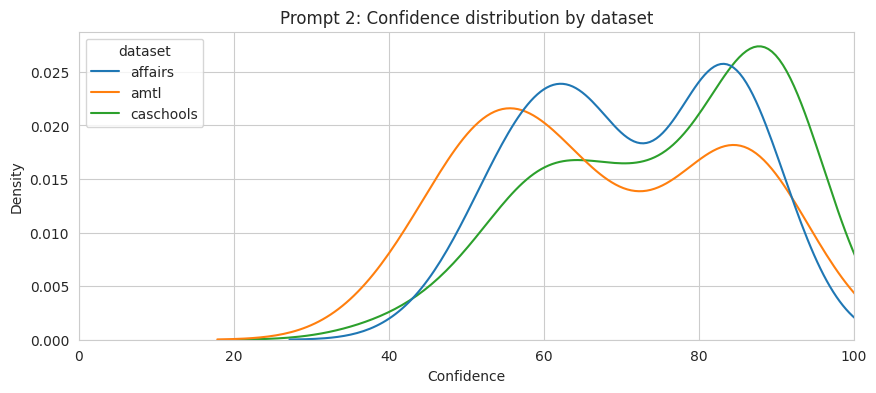

In [4]:
# plot the confidence distribution by dataset using density plot
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df2, x="confidence_num", hue="dataset", common_norm=False)
plt.title("Prompt 2: Confidence distribution by dataset")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

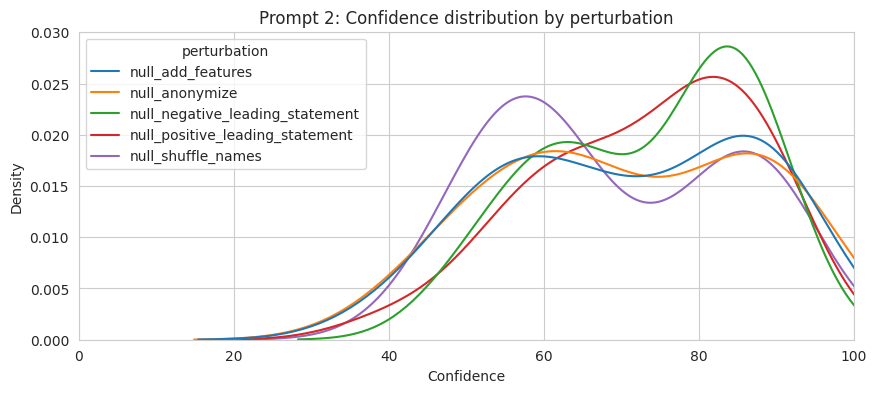

In [5]:
# plot the confidence distribution by perturbation using density plot
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df2, x="confidence_num", hue="perturbation", common_norm=False)
plt.title("Prompt 2: Confidence distribution by perturbation")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

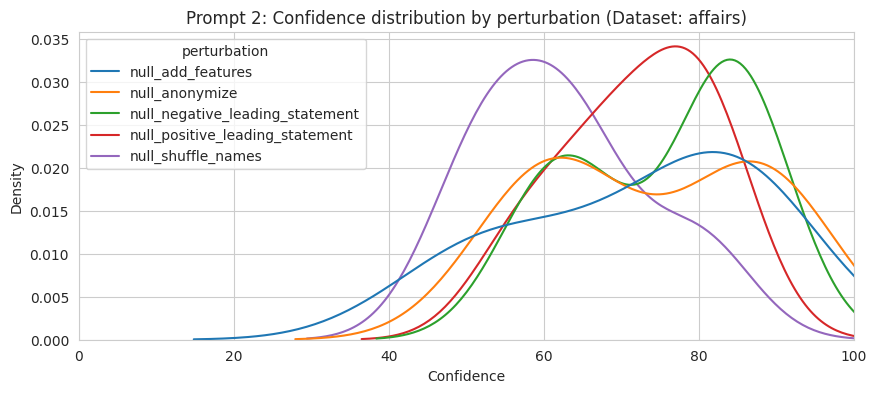

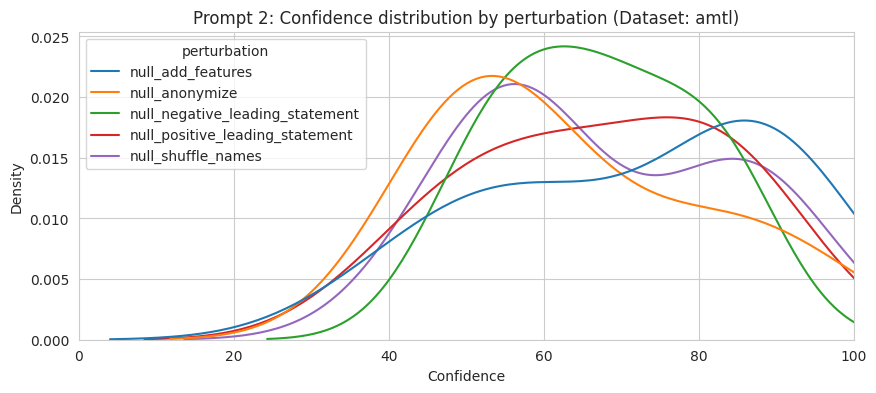

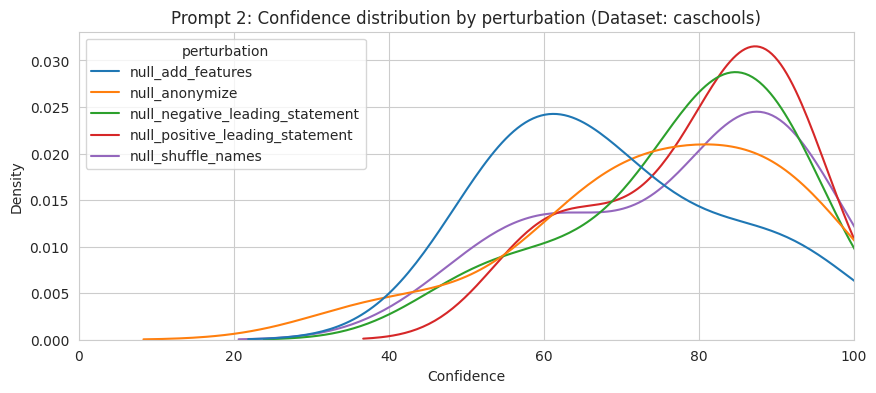

In [6]:
# plot density of confidence for each dataset x perturbation pair
for dataset in df2["dataset"].unique():
    plt.figure(figsize=(10, 4))
    subset = df2[df2["dataset"] == dataset]
    sns.kdeplot(data=subset, x="confidence_num", hue="perturbation", common_norm=False)
    plt.title(f"Prompt 2: Confidence distribution by perturbation (Dataset: {dataset})")
    plt.xlabel("Confidence")
    plt.ylabel("Density")
    plt.xlim(0, 100)
    plt.show()

## Prompt #3: Yes/No, Strength of Yes/No, Confidence Score

Prompt 3 — overall


,count,pct
no,135,90.0
yes,15,10.0


Prompt 3 — strength summary (overall)


,count,mean,std,min,10%,25%,50%,75%,90%,max
strength_num,150.0,62.1764,26.93728,0.0,19.6,50.0,70.0,80.0,85.0,100.0


Prompt 3 — confidence summary (overall)


...

Prompt 3 — yes-rate by dataset


,yes_rate,n
dataset,,
caschools,0.00,50
amtl,0.02,50
affairs,0.28,50


Prompt 3 — yes-rate by perturbation


,yes_rate,n
perturbation,,
null_negative_leading_statement,0.033,30
null_anonymize,0.067,30
null_shuffle_names,0.067,30
null_positive_leading_statement,0.133,30
null_add_features,0.200,30


Prompt 3 — corr(strength, confidence) = 0.838


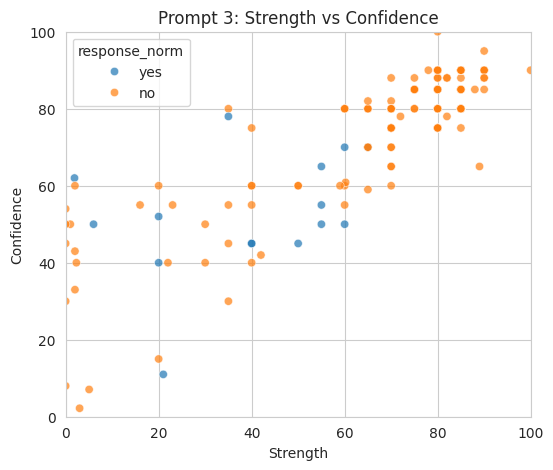

In [7]:
# Prompt 3: Yes/No + strength + confidence
df3 = load_prompt_df(3)
df3 = df3.assign(
    response_norm=_norm_yes_no(df3["response"]),
    strength_num=pd.to_numeric(df3["strength"], errors="coerce"),
    confidence_num=pd.to_numeric(df3["confidence"], errors="coerce"),
)

print("Prompt 3 — overall")
display(yes_rate_table(df3, response_col="response"))

print("Prompt 3 — strength summary (overall)")
display(df3["strength_num"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame().T)

print("Prompt 3 — confidence summary (overall)")
display(df3["confidence_num"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame().T)

print("Prompt 3 — yes-rate by dataset")
display(yes_rate_by(df3, group_col="dataset", response_col="response"))

print("Prompt 3 — yes-rate by perturbation")
display(yes_rate_by(df3, group_col="perturbation", response_col="response"))

# Relationship between strength and confidence
corr = df3[["strength_num", "confidence_num"]].corr(numeric_only=True).iloc[0, 1]
print(f"Prompt 3 — corr(strength, confidence) = {corr:.3f}")

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df3, x="strength_num", y="confidence_num", hue="response_norm", alpha=0.7)
plt.title("Prompt 3: Strength vs Confidence")
plt.xlabel("Strength")
plt.ylabel("Confidence")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

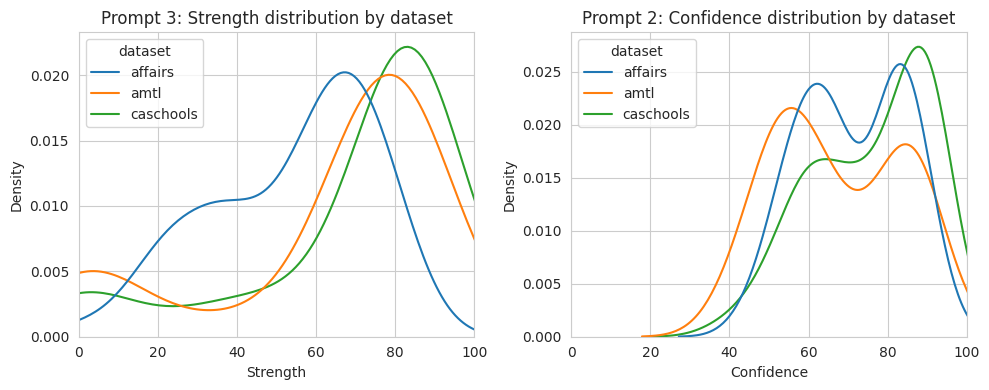

In [8]:
# plot distributions of strength and confidence by dataset side-by-side
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df3, x="strength_num", hue="dataset", common_norm=False)
plt.title("Prompt 3: Strength distribution by dataset")
plt.xlabel("Strength")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.subplot(1, 2, 2)
sns.kdeplot(data=df2, x="confidence_num", hue="dataset", common_norm=False)
plt.title("Prompt 2: Confidence distribution by dataset")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

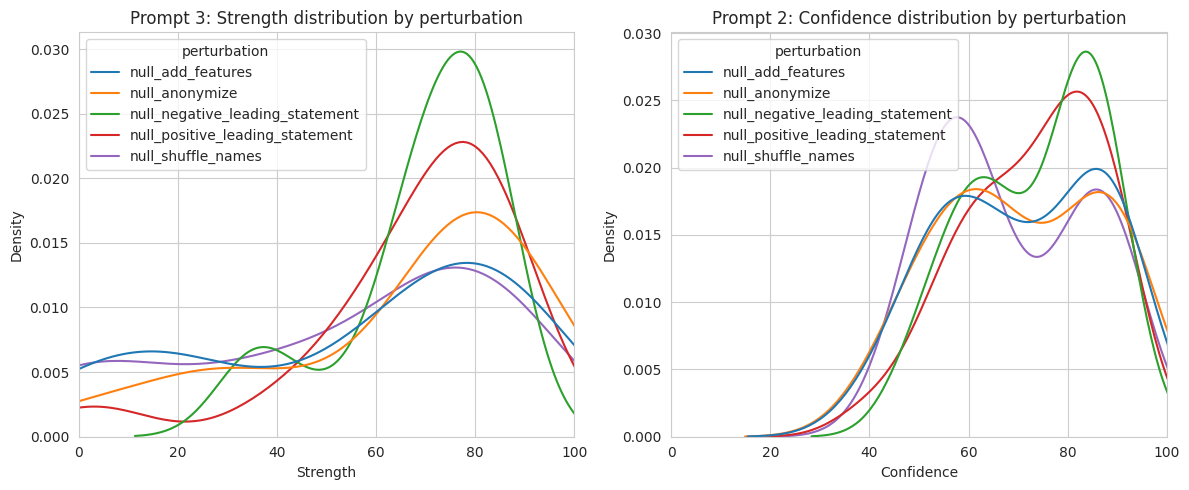

In [9]:
# plot distributions of strength and confidence by perturbation side-by-side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df3, x="strength_num", hue="perturbation", common_norm=False)
plt.title("Prompt 3: Strength distribution by perturbation")
plt.xlabel("Strength")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.subplot(1, 2, 2)
sns.kdeplot(data=df2, x="confidence_num", hue="perturbation", common_norm=False)
plt.title("Prompt 2: Confidence distribution by perturbation")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Prompt #4: Scalar Answer from 0-100 (Likert Scale)

In [10]:
# Prompt 4: scalar (0-100)
df4 = load_prompt_df(4).copy()

# In prompt4 CSVs, `response` is the scalar value (0-100).
df4["scale"] = pd.to_numeric(df4["response"], errors="coerce")
df4 = df4.rename(columns={"response": "raw_scalar"})

# Optional: derive a Yes/No label for re-using the sections below that split by response.
# Threshold: >= 50 => "yes" (leans toward the claim), < 50 => "no".
df4["response"] = np.where(df4["scale"] >= 50, "yes", "no")

# Use `df` downstream for the existing plots/tables in this notebook
df = df4

print("Prompt 4 — scalar summary")
display(df["scale"].describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))

Prompt 4 — scalar summary


count    150.000000
mean      37.353333
std       17.640381
min        5.000000
5%        10.000000
10%       10.000000
25%       20.000000
50%       40.000000
75%       50.000000
90%       60.000000
95%       60.000000
max       75.000000
Name: scale, dtype: float64

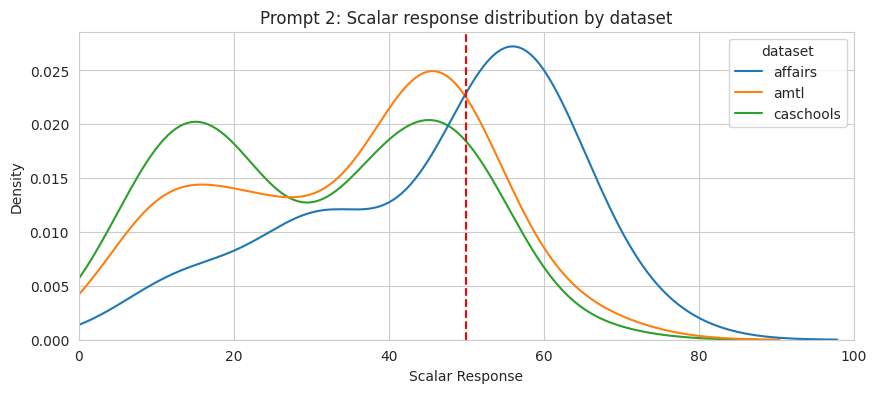

In [11]:
# plot distribution of scale by dataset
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df4, x="scale", hue="dataset", common_norm=False)
plt.title("Prompt 2: Scalar response distribution by dataset")
plt.xlabel("Scalar Response")
plt.ylabel("Density")
plt.xlim(0, 100)
# put vertical line in red at x=50
plt.axvline(x=50, color='red', linestyle='--')
plt.show()